<a href="https://colab.research.google.com/github/AKookani/MyDeepLearning/blob/main/Segmentation_with_U_Net1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset loading

##From Kaggle to cash

In [ ]:
import sys, tensorflow as tf, torch, platform, pip
import pkg_resources

print("Python:", sys.version)
print("TensorFlow:", tf.__version__ if "tf" in globals() else "not installed")
print("PyTorch:", torch.__version__ if "torch" in globals() else "not installed")
print("CUDA available (torch):", torch.cuda.is_available())
print("Platform:", platform.platform())

# List installed packages (long output)
packages = {d.project_name: d.version for d in pkg_resources.working_set}
print("Installed packages:", packages)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
PyTorch: 2.9.0+cu126
CUDA available (torch): True
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
Installed packages: {'Bottleneck': '1.4.2', 'Cython': '3.0.12', 'Farama-Notifications': '0.0.4', 'GDAL': '3.8.4', 'PyDrive2': '1.21.3', 'PyJWT': '2.10.1', 'PySocks': '1.7.1', 'absl-py': '1.4.0', 'accelerate': '1.12.0', 'access': '1.1.10.post3', 'affine': '2.4.0', 'aiofiles': '24.1.0', 'aiohappyeyeballs': '2.6.1', 'aiohttp': '3.13.3', 'aiosignal': '1.4.0', 'aiosqlite': '0.22.1', 'alabaster': '1.0.0', 'albucore': '0.0.24', 'albumentations': '2.0.8', 'ale-py': '0.11.2', 'alembic': '1.18.1', 'altair': '5.5.0', 'annotated-doc': '0.0.4', 'annotated-types': '0.7.0', 'antlr4-python3-runtime': '4.9.3', 'anyio': '4.12.1', 'anywidget': '0.9.21', 'apsw': '3.51.2.0', 'apswutils': '0.1.2', 'argon2-cffi': '25.1.0', 'argon2-cffi-bindings': '25.1.0', 'array-record': '0.8.3', 'arrow': '1.4.0', 'arviz': '0.22.0', 'astropy': '7.2.0',

/tmp/ipython-input-2595127847.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("trantoanthang/isic-2018")

# print("the first location of the dataset is:", path)

## Change the directory from cash to content

In [ ]:
# import shutil
# import os

# destination = "/content/isic-2018"

# # Remove destination if it already exists (optional)
# if os.path.exists(destination):
#     shutil.rmtree(destination)

# # Move the downloaded dataset to a fixed, known directory
# shutil.move(path, destination)

# print("Dataset moved to:", destination)

##Dependencies

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

##Data Addressing and Exhibition

In [ ]:
# Define constants for image size, batch size, and random seed
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

In [ ]:
# Set base directory and subdirectories for images and masks
target_dir = destination
mask_train_dir = os.path.join(target_dir, 'data', 'annotations', 'train')
image_train_dir = os.path.join(target_dir, 'data', 'images', 'train')

In [ ]:
# Get last 5 image and mask file paths (excluding .txt files)
images = [os.path.join(image_train_dir, i) for i in sorted(os.listdir(image_train_dir))[-5:] if i[-3:] != 'txt']
masks = [os.path.join(mask_train_dir, i) for i in sorted(os.listdir(mask_train_dir))[-5:] if i[-3:] != 'txt']

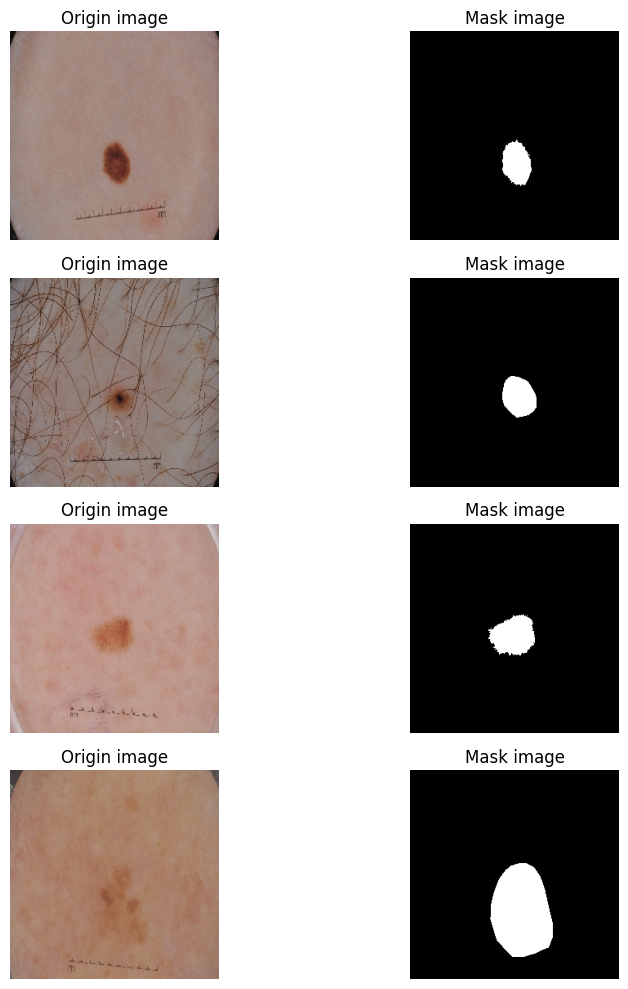

In [ ]:
# Create a 4x2 subplot to visualize sample images and masks
fig, axe = plt.subplots(4, 2, figsize=(10,10))

for i in range(4):
    for j in range(2):
        if j == 0:
          # Load, resize, and convert image from BGR to RGB
            image = cv2.imread(images[i])
            image = cv2.resize(image, IMG_SIZE)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            axe[i, j].imshow(image)
            axe[i, j].set_title('Origin image')
            axe[i, j].axis('off')
        else:
          # Load, resize, and convert mask to grayscale
            mask = cv2.imread(masks[i])
            mask = cv2.resize(mask, IMG_SIZE)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

            axe[i, j].imshow(mask, cmap='gray')
            axe[i, j].set_title('Mask image')
            axe[i, j].axis('off')

# Adjust layout and display the figure
plt.tight_layout()
plt.show()

## Prepare image-mask pairs

In [ ]:
# Load and preprocess a single image-mask pair using TensorFlow operations
def load_images(images_path, masks_path):
    image = tf.io.read_file(images_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

# Read and decode mask as PNG, resize, reduce channels, normalize, and binarize
    mask = tf.io.read_file(masks_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE)
    mask = tf.reduce_mean(mask, axis=-1, keepdims=True)
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.round(mask)

    return image, mask

In [ ]:
# Build a TensorFlow dataset from image and mask directories
def build_dataset(images_dir, masks_dir):
    images_path = sorted([os.path.join(images_dir, i) for i in os.listdir(images_dir) if i.lower().endswith(('.jpg', '.jpeg', '.png'))])
    masks_path = sorted([os.path.join(masks_dir, i) for i in os.listdir(masks_dir) if i.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Create a dataset from file paths and map to loaded/preprocessed tensors
    dataset = tf.data.Dataset.from_tensor_slices((images_path, masks_path))
    dataset = dataset.map(load_images, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Build training, validation, and test datasets from respective directories
train_ds = build_dataset('/content/isic-2018/data/images/train', '/content/isic-2018/data/annotations/train')
test_ds = build_dataset('/content/isic-2018/data/images/test', '/content/isic-2018/data/annotations/test')
val_ds = build_dataset('/content/isic-2018/data/images/val', '/content/isic-2018/data/annotations/val')

# Build U-Net

## proposed U-Net

In [ ]:
# # Define input layer for the model
# inputs = keras.layers.Input(shape=IMG_SIZE + (3,))

# # ===== Encoder =====

# # Block 1
# c1 = keras.layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(inputs)
# c1 = keras.layers.BatchNormalization()(c1)
# c1 = keras.layers.Activation('relu')(c1)

# c1 = keras.layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(c1)
# c1 = keras.layers.BatchNormalization()(c1)
# c1 = keras.layers.Activation('relu')(c1)

# p1 = keras.layers.MaxPooling2D((2,2))(c1)

# # Block 2
# c2 = keras.layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(p1)
# c2 = keras.layers.BatchNormalization()(c2)
# c2 = keras.layers.Activation('relu')(c2)

# c2 = keras.layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(c2)
# c2 = keras.layers.BatchNormalization()(c2)
# c2 = keras.layers.Activation('relu')(c2)

# p2 = keras.layers.MaxPooling2D((2,2))(c2)

# # Block 3
# c3 = keras.layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(p2)
# c3 = keras.layers.BatchNormalization()(c3)
# c3 = keras.layers.Activation('relu')(c3)

# c3 = keras.layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(c3)
# c3 = keras.layers.BatchNormalization()(c3)
# c3 = keras.layers.Activation('relu')(c3)

# p3 = keras.layers.MaxPooling2D((2,2))(c3)

# # ===== Bottleneck =====

# c4 = keras.layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(p3)
# c4 = keras.layers.BatchNormalization()(c4)
# c4 = keras.layers.Activation('relu')(c4)

# c4 = keras.layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(c4)
# c4 = keras.layers.BatchNormalization()(c4)
# c4 = keras.layers.Activation('relu')(c4)

# # ===== Decoder =====

# u1 = keras.layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c4)
# u1 = keras.layers.concatenate([u1, c3])

# c5 = keras.layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(u1)
# c5 = keras.layers.BatchNormalization()(c5)
# c5 = keras.layers.Activation('relu')(c5)

# c5 = keras.layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(c5)
# c5 = keras.layers.BatchNormalization()(c5)
# c5 = keras.layers.Activation('relu')(c5)

# u2 = keras.layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c5)
# u2 = keras.layers.concatenate([u2, c2])

# c6 = keras.layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(u2)
# c6 = keras.layers.BatchNormalization()(c6)
# c6 = keras.layers.Activation('relu')(c6)

# c6 = keras.layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(c6)
# c6 = keras.layers.BatchNormalization()(c6)
# c6 = keras.layers.Activation('relu')(c6)

# u3 = keras.layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c6)
# u3 = keras.layers.concatenate([u3, c1])

# c7 = keras.layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(u3)
# c7 = keras.layers.BatchNormalization()(c7)
# c7 = keras.layers.Activation('relu')(c7)

# c7 = keras.layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(c7)
# c7 = keras.layers.BatchNormalization()(c7)
# c7 = keras.layers.Activation('relu')(c7)

# # ===== Output =====

# outputs = keras.layers.Conv2D(1, 1, activation='sigmoid')(c7)

# model = keras.Model(inputs, outputs)

In [ ]:
# tf.keras.utils.plot_model(model, to_file="my_model.png", show_shapes=True)

In [ ]:
# model.summary()

## baseline Autoencoder

In [ ]:
# Define input layer for the model
inputs = keras.layers.Input(shape=IMG_SIZE + (3,))

# ===== Encoder =====

# Block 1
c1 = keras.layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(inputs)
c1 = keras.layers.BatchNormalization()(c1)
c1 = keras.layers.Activation('relu')(c1)

# c1 = keras.layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(c1)
# c1 = keras.layers.BatchNormalization()(c1)
# c1 = keras.layers.Activation('relu')(c1)

p1 = keras.layers.MaxPooling2D((2,2))(c1)

# Block 2
c2 = keras.layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(p1)
c2 = keras.layers.BatchNormalization()(c2)
c2 = keras.layers.Activation('relu')(c2)

# c2 = keras.layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(c2)
# c2 = keras.layers.BatchNormalization()(c2)
# c2 = keras.layers.Activation('relu')(c2)

p2 = keras.layers.MaxPooling2D((2,2))(c2)

# Block 3
c3 = keras.layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(p2)
c3 = keras.layers.BatchNormalization()(c3)
c3 = keras.layers.Activation('relu')(c3)

# c3 = keras.layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(c3)
# c3 = keras.layers.BatchNormalization()(c3)
# c3 = keras.layers.Activation('relu')(c3)

p3 = keras.layers.MaxPooling2D((2,2))(c3)

# ===== Bottleneck =====

c4 = keras.layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(p3)
c4 = keras.layers.BatchNormalization()(c4)
c4 = keras.layers.Activation('relu')(c4)

# c4 = keras.layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(c4)
# c4 = keras.layers.BatchNormalization()(c4)
# c4 = keras.layers.Activation('relu')(c4)

# ===== Decoder =====

u1 = keras.layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c4)
#u1 = keras.layers.concatenate([u1, c3])

#c5 = keras.layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(u1)
c5 = keras.layers.BatchNormalization()(u1)
c5 = keras.layers.Activation('relu')(c5)

# c5 = keras.layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(c5)
# c5 = keras.layers.BatchNormalization()(c5)
# c5 = keras.layers.Activation('relu')(c5)

u2 = keras.layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c5)
#u2 = keras.layers.concatenate([u2, c2])

#c6 = keras.layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(u2)
c6 = keras.layers.BatchNormalization()(u2)
c6 = keras.layers.Activation('relu')(c6)

# c6 = keras.layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(c6)
# c6 = keras.layers.BatchNormalization()(c6)
# c6 = keras.layers.Activation('relu')(c6)

u3 = keras.layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c6)
#u3 = keras.layers.concatenate([u3, c1])

#c7 = keras.layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(u3)
c7 = keras.layers.BatchNormalization()(u3)
c7 = keras.layers.Activation('relu')(c7)

# c7 = keras.layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(c7)
# c7 = keras.layers.BatchNormalization()(c7)
# c7 = keras.layers.Activation('relu')(c7)

# ===== Output =====

outputs = keras.layers.Conv2D(1, 1, activation='sigmoid')(c7)

model = keras.Model(inputs, outputs)

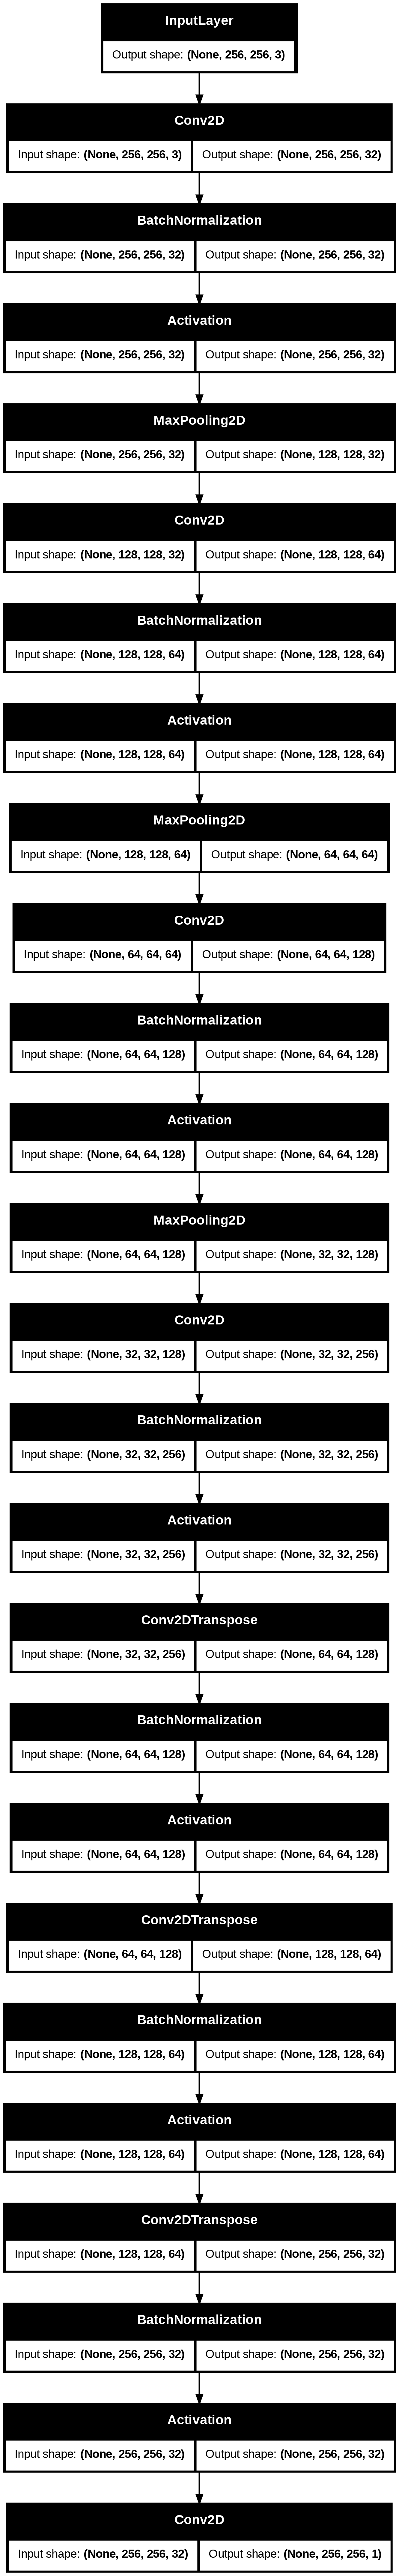

In [ ]:
tf.keras.utils.plot_model(model, to_file="my_model.png", show_shapes=True)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 128)    │       131,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 128, 64)   │        32,832 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 563,521 (2.15 MB)

 Trainable params: 562,113 (2.14 MB)

 Non-trainable params: 1,408 (5.50 KB)

# Model training

## Loss & Metric

<details>
  <summary><strong>Dice Loss & IoU formula (click to expand)</strong></summary>

**Dice Loss**

The **Dice coefficient** (also known as the F1 score for segmentation) measures the overlap between the predicted mask $y_\text{pred}$ and the ground truth mask $y_\text{true}$:

$$
\text{Dice}(y_\text{true}, y_\text{pred}) =
\frac{2 \cdot |y_\text{true} \cap y_\text{pred}| + \varepsilon}
{|y_\text{true}| + |y_\text{pred}| + \varepsilon}
$$

The **Dice loss** is then:

$$
\mathcal{L}_\text{Dice} = 1 - \text{Dice}(y_\text{true}, y_\text{pred})
$$

---

**IoU (Intersection over Union) Metric**

Also known as the **Jaccard Index**, IoU measures the ratio of the intersection to the union:

$$
\text{IoU}(y_\text{true}, y_\text{pred}) =
\frac{|y_\text{true} \cap y_\text{pred}| + \varepsilon}
{|y_\text{true} \cup y_\text{pred}| + \varepsilon}
$$

</details>


<details>
  <summary><strong>Dice Loss & IoU conception (click to expand)</strong></summary>

IoU: Overlap area divided by total combined area of predicted and true segments.
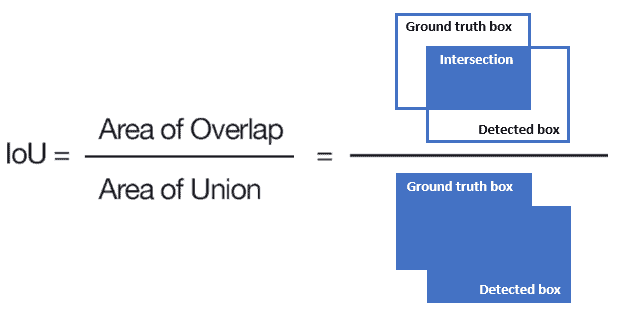

Dice: Twice overlap area divided by (predicted area + true area).
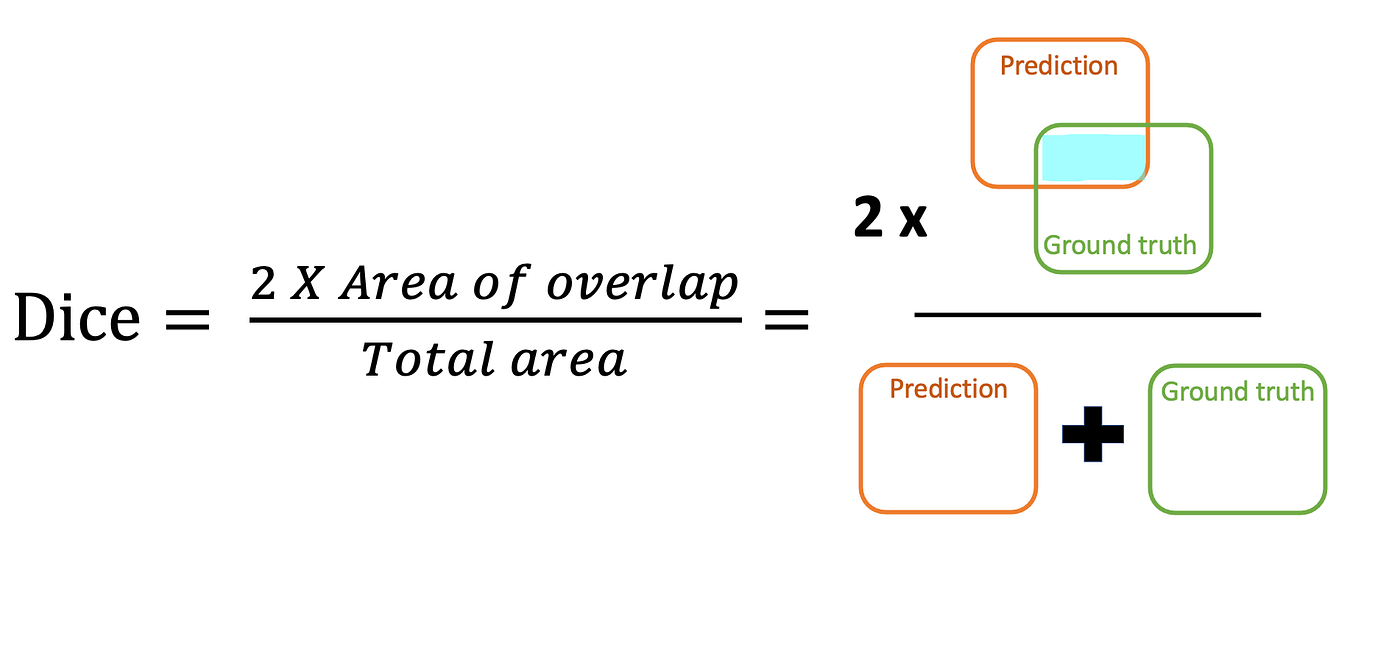

In [ ]:
import tensorflow.keras.backend as K
from tensorflow.keras.losses import BinaryCrossentropy

# Define Dice loss for segmentation (measures overlap)
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Instantiate binary crossentropy loss
bce = BinaryCrossentropy()

# Combine BCE and Dice loss for better optimization stability
def combined_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

# Define Dice coefficient as a metric (higher = better)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Define Intersection-over-Union (IoU) metric
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop

# Compile model with Adam optimizer and custom loss/metrics
model.compile(
  optimizer=RMSprop(learning_rate=0.01), # you can adjust the lr
  loss=combined_loss,
  metrics=[dice_coef, iou_metric]
)

## Learning process

In [ ]:
# Train the model for 10 epochs using train and validation datasets
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    verbose=1
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1345s 16s/step - dice_coef: 0.5150 - iou_metric: 0.3625 - loss: 0.9536 - val_dice_coef: 0.5012 - val_iou_metric: 0.3547 - val_loss: 1.3709
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1385s 17s/step - dice_coef: 0.6174 - iou_metric: 0.4617 - loss: 0.7587 - val_dice_coef: 0.6645 - val_iou_metric: 0.5045 - val_loss: 1.3977
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1404s 17s/step - dice_coef: 0.6404 - iou_metric: 0.4854 - loss: 0.7063 - val_dice_coef: 0.6259 - val_iou_metric: 0.4573 - val_loss: 1.0577
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1385s 17s/step - dice_coef: 0.6439 - iou_metric: 0.4894 - loss: 0.6947 - val_dice_coef: 0.6458 - val_iou_metric: 0.4795 - val_loss: 0.9351
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1357s 17s/step - dice_coef: 0.6548 - iou_metric: 0.5007 - loss: 0.6730 - val_dice_coef: 0.6200 - val_iou_metric: 0.4522 - val_loss: 0.8478
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1377s 17s/step - dice_coef: 0.6567 - iou_metric: 0.5023 - loss: 0.6720 - val_

# Visualization

In [ ]:
# Plot training and validation loss and metrics
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot loss
axs[0].plot(history.history['loss'], label='Train Loss')
axs[0].plot(history.history['val_loss'], label='Val Loss')
axs[0].set_title('Model Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

# Plot Dice coefficient
axs[1].plot(history.history['dice_coef'], label='Train Dice')
axs[1].plot(history.history['val_dice_coef'], label='Val Dice')
axs[1].set_title('Dice Coefficient')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Dice')
axs[1].legend()

# Plot IoU
axs[2].plot(history.history['iou_metric'], label='Train IoU')
axs[2].plot(history.history['val_iou_metric'], label='Val IoU')
axs[2].set_title('IoU Metric')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('IoU')
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Get a batch of validation data for visualization
sample_batch = next(iter(val_ds))
sample_images, sample_masks = sample_batch

# Run inference
sample_predictions = model.predict(sample_images)

# Plot comparisons
num_examples = min(4, sample_images.shape[0])  # Show up to 4 examples
fig, axes = plt.subplots(num_examples, 3, figsize=(10, num_examples * 3))

# Handle case where num_examples == 1 (axes not a list)
if num_examples == 1:
    axes = [axes]

for i in range(num_examples):
    # Original image
    img = sample_images[i].numpy()
    axes[i][0].imshow(img)
    axes[i][0].set_title("Input Image")
    axes[i][0].axis("off")

    # Ground truth mask
    gt_mask = sample_masks[i].numpy().squeeze()
    axes[i][1].imshow(gt_mask, cmap="gray")
    axes[i][1].set_title("Ground Truth")
    axes[i][1].axis("off")

    # Predicted mask (apply threshold 0.5 to get binary output)
    pred_mask = (sample_predictions[i].squeeze() > 0.5).astype(np.float32)
    axes[i][2].imshow(pred_mask, cmap="gray")
    axes[i][2].set_title("Prediction (threshold=0.5)")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()

# Save the model

In [ ]:
model.save("/content/isic_unet_model.keras")

# Load model & Evaluation

## Duplicate code to run the code from this part

In [ ]:
import tensorflow.keras.backend as K
from tensorflow.keras.losses import BinaryCrossentropy

# Define Dice loss for segmentation (measures overlap)
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Instantiate binary crossentropy loss
bce = BinaryCrossentropy()

# Combine BCE and Dice loss for better optimization stability
def combined_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

# Define Dice coefficient as a metric (higher = better)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Define Intersection-over-Union (IoU) metric
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Load model with custom objects
loaded_model = keras.models.load_model(
    "/content/isic_unet_model.keras",
    custom_objects={
        'combined_loss': combined_loss,
        'dice_coef': dice_coef,
        'iou_metric': iou_metric
    }
)

In [ ]:
# Evaluate using the same metrics the model was compiled with
test_results = loaded_model.evaluate(test_ds, verbose=1)

# Print results
loss, dice, iou = test_results
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Dice Coefficient: {dice:.4f}")
print(f"Test IoU: {iou:.4f}")

In [ ]:
# Get a batch of validation data for visualization
sample_batch = next(iter(test_ds))
sample_images, sample_masks = sample_batch

# Run inference
sample_predictions = loaded_model.predict(sample_images)

# Plot comparisons
num_examples = min(4, sample_images.shape[0])  # Show up to 4 examples
fig, axes = plt.subplots(num_examples, 3, figsize=(10, num_examples * 3))

# Handle case where num_examples == 1 (axes not a list)
if num_examples == 1:
    axes = [axes]

for i in range(num_examples):
    # Original image
    img = sample_images[i].numpy()
    axes[i][0].imshow(img)
    axes[i][0].set_title("Input Image")
    axes[i][0].axis("off")

    # Ground truth mask
    gt_mask = sample_masks[i].numpy().squeeze()
    axes[i][1].imshow(gt_mask, cmap="gray")
    axes[i][1].set_title("Ground Truth")
    axes[i][1].axis("off")

    # Predicted mask (apply threshold 0.5 to get binary output)
    pred_mask = (sample_predictions[i].squeeze() > 0.5).astype(np.float32)
    axes[i][2].imshow(pred_mask, cmap="gray")
    axes[i][2].set_title("Prediction (threshold=0.5)")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()